# 02 — τ̃ contra V y contra la literatura: ¿aporta algo nuevo?

**Pregunta que se probó:** El observable normalizado τ̃ (derivado del segundo
momento espectral) — ¿carga información estructural que V no tiene? Se
definió un criterio de éxito ANTES de correr el experimento: τ̃ debía superar
a V por ≥0.15 en al menos 2 de 4 tareas de estructura de comunidades
(participación, grado intra-módulo, detección de nodos frontera).

**Resultado:** REFUTADO. τ̃ nunca superó a V en ninguna de las tareas
probadas, ni siquiera en su terreno teóricamente favorable (estructura de
módulos, por su sensibilidad a modos espectrales lentos). También se verifica
aquí que V ≠ current-flow closeness centrality (Spearman ≈ −1.0 pero Pearson
≈ −0.82 — ordenan igual, no son la misma cantidad).

Ver detalle completo en `paper/SPG_final_v9.docx`, Secciones 3 y 4.


## Fuentes de datos

- **C. elegans interactomes** (Genetic.csv)
  https://networks.skewed.de/net/celegans_interactomes
- **C. elegans neural** (Neurons.csv)
  https://networks.skewed.de/net/celegansneural
- **C. elegans metabolic**
  https://networks.skewed.de/net/celegans_metabolic
- **Bitcoin trust**
  https://networks.skewed.de/net/bitcoin_trust
- **Bitcoin alpha**
  https://networks.skewed.de/net/bitcoin_alpha
- **Fly larva**
  https://networks.skewed.de/net/fly_larva
- **Food web (Little Rock)**
  https://networks.skewed.de/net/foodweb_little_rock
- **Interactome PDZ**
  https://networks.skewed.de/net/interactome_pdz
- **Interactome Stelzl**
  https://networks.skewed.de/net/interactome_stelzl
- **Jazz collaboration network**
  https://networks.skewed.de/net/jazz_collab


> **Nota:** de cada dataset se usó únicamente el archivo de tipo `edges` (lista de aristas). No se usaron archivos de nodos ni de metadatos adicionales de Netzschleuder.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
CARPETA = '/content/drive/MyDrive/PYTHON/C.Elegans CSV'
print("¿existe la carpeta?:", os.path.isdir(CARPETA))
if os.path.isdir(CARPETA):
    print("archivos que veo:")
    for f in sorted(os.listdir(CARPETA)):
        print("  ", f)

¿existe la carpeta?: True
archivos que veo:
   Budapest
   CSV
   Experimental
   HumanBrain
   Neurons.csv
   Romper
   bitcoin_alpha.csv
   celegans_metabolic.csv
   foodweb_little_rock.csv
   jazz_collab.csv


In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import os
import matplotlib.pyplot as plt
from scipy.linalg import eigh
from scipy.stats import spearmanr, pearsonr

print("✓ librerías cargadas")


✓ librerías cargadas


In [ ]:
class SPG:
    """
    Observables de tu marco, calculados desde el espectro del Laplaciano
    combinatorio L = D - A, excluyendo el modo cero (k=1, lambda=0).

    V         : visibilidad espectral = sum_{k>=2} v_k(i)^2 / lambda_k
                (afirmamos que esto = L+_ii, la diagonal de la pseudoinversa)
    tau        : timescale = M2/M1
    tau_tilde  : timescale normalizado = lambda_2 * tau
    """
    def __init__(self, A):
        A = np.array(A, float); np.fill_diagonal(A, 0)
        N = A.shape[0]; deg = A.sum(1)
        ev, evec = eigh(np.diag(deg) - A)
        k0 = next((k for k in range(1, N) if ev[k] > 1e-8), None)
        if k0 is None:
            raise ValueError("grafo desconectado (lambda_2 = 0)")
        M1 = np.zeros(N); M2 = np.zeros(N)
        for k in range(k0, N):
            if ev[k] < 1e-10:
                continue
            v2 = evec[:, k]**2
            M1 += v2 / ev[k]
            M2 += v2 / ev[k]**2
        self.V         = M1                                  # = L+_ii (a verificar)
        self.tau       = np.where(M1 > 1e-14, M2/M1, 0)
        self.tau_tilde = ev[k0] * self.tau
        self.degree    = deg
        self.eigenvalues = ev
        self.lambda2   = ev[k0]
        self.N         = N

print("✓ clase SPG definida (V, tau, tau_tilde)")


✓ clase SPG definida (V, tau, tau_tilde)


In [ ]:
G = nx.star_graph(19)
s = SPG(nx.to_numpy_array(G))
print(f"Star S_20: tau_hub={s.tau[0]:.4f} (teoría 1/N=0.0500), "
      f"tau_leaf={s.tau[1]:.4f} (teoría 1.0000)")
assert abs(s.tau[0]-0.05) < 0.01, "FALLA el control"
print("✓ pipeline validado contra solución analítica")


Star S_20: tau_hub=0.0500 (teoría 1/N=0.0500), tau_leaf=0.9999 (teoría 1.0000)
✓ pipeline validado contra solución analítica


In [ ]:
def cargar_red(archivo):
    """CSV de aristas -> grafo no dirigido, sin self-loops, componente conexa mayor."""
    df = pd.read_csv(archivo, comment='#', header=None).iloc[:, :2]
    df.columns = ['s', 't']
    G = nx.Graph(); G.add_edges_from(df.values)
    G.remove_edges_from(nx.selfloop_edges(G))
    G = G.subgraph(max(nx.connected_components(G), key=len)).copy()
    return G

def observables_literatura(G):
    """Calcula los observables conocidos de la literatura."""
    nodes = list(G.nodes())
    A = nx.to_numpy_array(G, nodelist=nodes)
    L = np.diag(A.sum(1)) - A
    # L+_ii : diagonal de la pseudoinversa (Van Mieghem 2017, Klein-Randic 1993)
    Lplus_diag = np.diag(np.linalg.pinv(L))
    # current-flow closeness (Brandes-Fleischer 2005) — NO es lo mismo que L+_ii
    cfc = np.array([nx.current_flow_closeness_centrality(G)[n] for n in nodes])
    # closeness clásica
    clo = np.array([nx.closeness_centrality(G)[n] for n in nodes])
    deg = np.array([G.degree(n) for n in nodes])
    return dict(nodes=nodes, degree=deg, Lplus_diag=Lplus_diag,
                current_flow=cfc, closeness=clo)

print("✓ loader y observables de literatura listos")


✓ loader y observables de literatura listos


In [ ]:
# Carpeta donde tienes los CSV. Ajusta a tu ruta real.
CARPETA = '/content/drive/MyDrive/PYTHON/C.Elegans CSV'

# Etiqueta cada red con su dominio. Ajusta los nombres de archivo a los tuyos.
# Necesitas AL MENOS 2 biológicas y 2 no biológicas.
REDES = [
    # (archivo,                  nombre_corto,        dominio)
    ('celegans_metabolic.csv',   'C. elegans metab',  'biológico'),
    ('foodweb_little_rock.csv',  'food web',          'biológico'),
    ('Neurons.csv',              'C. elegans neural', 'biológico'),
    ('jazz_collab.csv',          'jazz',              'no biológico'),
    ('bitcoin_alpha.csv',        'bitcoin',           'no biológico'),
]

# verificar que existen
print("verificando archivos:")
for arch, nom, dom in REDES:
    ruta = os.path.join(CARPETA, arch)
    existe = os.path.isfile(ruta)
    print(f"  [{'OK' if existe else 'FALTA'}] {arch}  ({dom})")


verificando archivos:
  [OK] celegans_metabolic.csv  (biológico)
  [OK] foodweb_little_rock.csv  (biológico)
  [OK] Neurons.csv  (biológico)
  [OK] jazz_collab.csv  (no biológico)
  [OK] bitcoin_alpha.csv  (no biológico)


In [ ]:
import os
import numpy as np
import networkx as nx
from scipy.stats import spearmanr
from tqdm import tqdm  # pip install tqdm

MAX_NODOS = 2000  # Ajusta este límite según la capacidad de tu equipo

print(f"{'red':20s} {'dominio':14s} {'V==L+ii?':>10s} {'dif_max':>10s} {'V vs CFC':>10s}")
print("-" * 70)

resultados = []

for arch, nom, dom in tqdm(REDES, desc="Procesando redes"):
    ruta = os.path.join(CARPETA, arch)
    if not os.path.isfile(ruta):
        continue

    try:
        G = cargar_red(ruta)

        # 1. Filtro de seguridad por número de nodos
        if G.number_of_nodes() > MAX_NODOS:
            print(f"{nom:20s} OMITIDA (demasiados nodos: {G.number_of_nodes()})")
            continue

        # 2. Convertir a matriz (evita volver a listar nodos manualmente)
        adj_matrix = nx.to_numpy_array(G)
        s = SPG(adj_matrix)
        lit = observables_literatura(G)

        # 3. Comparaciones
        dif = np.max(np.abs(s.V - lit['Lplus_diag']))
        ident = np.allclose(s.V, lit['Lplus_diag'])
        sp_cfc = spearmanr(s.V, lit['current_flow'])[0]

        print(f"{nom:20s} {dom:14s} {str(ident):>10s} {dif:>10.2e} {sp_cfc:>+10.3f}")
        resultados.append(dict(nombre=nom, dominio=dom, G=G, spg=s, lit=lit))

    except Exception as e:
        print(f"{nom:20s} ERROR: {str(e)[:35]}")

red                  dominio          V==L+ii?    dif_max   V vs CFC
----------------------------------------------------------------------


Procesando redes:  20%|██        | 1/5 [03:41<14:46, 221.66s/it]

C. elegans metab     biológico            True   2.62e-14     -1.000


Procesando redes:  40%|████      | 2/5 [04:01<05:08, 102.95s/it]

food web             biológico            True   5.44e-15     -0.997


...

C. elegans neural    biológico            True   7.54e-15     -1.000


Procesando redes:  80%|████████  | 4/5 [05:39<01:04, 64.72s/it]

jazz                 no biológico         True   2.33e-14     -1.000


Procesando redes: 100%|██████████| 5/5 [05:39<00:00, 67.96s/it]

bitcoin              OMITIDA (demasiados nodos: 3775)


In [ ]:
print(f"{'red':20s} {'dominio':14s} {'gr-L+ii':>9s} {'gr-CFC':>9s} {'gr-clos':>9s} {'gr-tau~':>9s}")
print("-"*74)
tabla = []
for r in resultados:
    s, lit = r['spg'], r['lit']
    deg = lit['degree']
    sp_L   = spearmanr(deg, lit['Lplus_diag'])[0]
    sp_cfc = spearmanr(deg, lit['current_flow'])[0]
    sp_clo = spearmanr(deg, lit['closeness'])[0]
    sp_tt  = spearmanr(deg, s.tau_tilde)[0]
    print(f"{r['nombre']:20s} {r['dominio']:14s} {sp_L:>+9.3f} {sp_cfc:>+9.3f} "
          f"{sp_clo:>+9.3f} {sp_tt:>+9.3f}")
    tabla.append(dict(nombre=r['nombre'], dominio=r['dominio'],
                      sp_L=sp_L, sp_cfc=sp_cfc, sp_clo=sp_clo, sp_tt=sp_tt))

# resumen por dominio
import numpy as np
for dom in ['biológico', 'no biológico']:
    vals = [x['sp_L'] for x in tabla if x['dominio']==dom]
    if vals:
        print(f"\n  {dom}: grado-L+ii medio = {np.mean(vals):+.3f} ± {np.std(vals):.3f}")
print("\n>>> Si bio y no-bio dan valores similares -> el efecto es TOPOLÓGICO, no biológico")


red                  dominio          gr-L+ii    gr-CFC   gr-clos   gr-tau~
--------------------------------------------------------------------------
C. elegans metab     biológico         -0.962    +0.962    +0.592    -0.844
food web             biológico         -0.996    +0.997    +0.911    -0.926
C. elegans neural    biológico         -0.998    +0.998    +0.738    -0.947
jazz                 no biológico      -0.998    +0.998    +0.890    -0.658

  biológico: grado-L+ii medio = -0.986 ± 0.016

  no biológico: grado-L+ii medio = -0.998 ± 0.000

>>> Si bio y no-bio dan valores similares -> el efecto es TOPOLÓGICO, no biológico


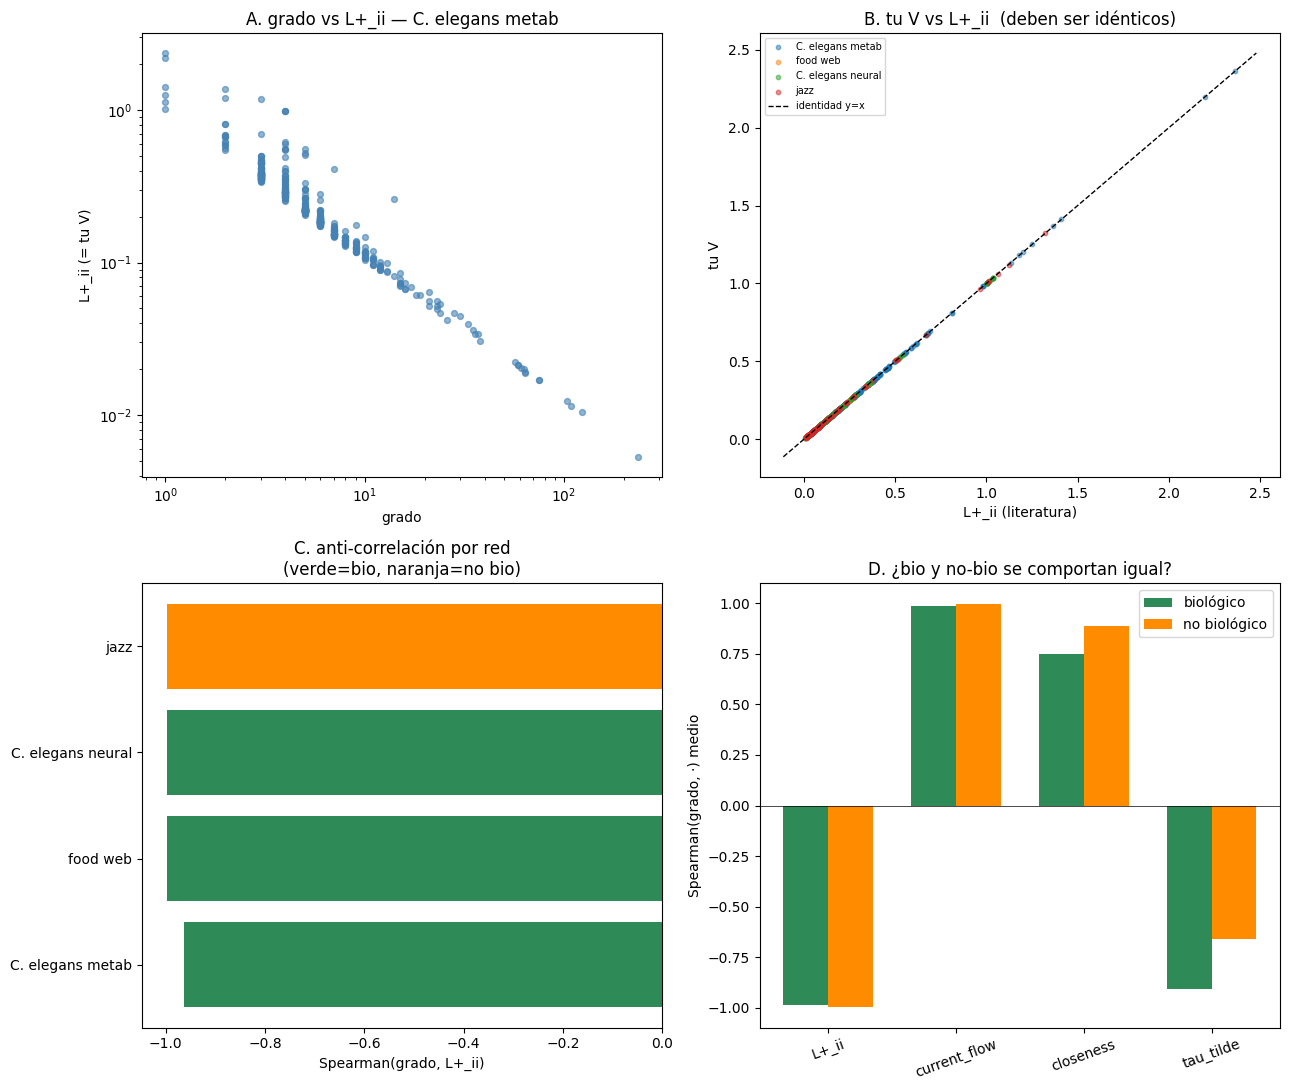

✓ figura guardada en /content/comparacion_dominios.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 11))

# Panel A: grado vs L+ii en una red (log-log), coloreado por dominio
ax = axes[0,0]
for r in resultados[:1]:  # una red de ejemplo
    lit = r['lit']
    ax.scatter(lit['degree'], lit['Lplus_diag'], s=18, alpha=0.6, c='steelblue')
ax.set_xlabel('grado'); ax.set_ylabel('L+_ii (= tu V)')
ax.set_title(f"A. grado vs L+_ii — {resultados[0]['nombre']}")
ax.set_xscale('log'); ax.set_yscale('log')

# Panel B: tu V vs L+ii literatura (deben caer en la diagonal)
ax = axes[0,1]
for r in resultados:
    ax.scatter(r['lit']['Lplus_diag'], r['spg'].V, s=10, alpha=0.5, label=r['nombre'])
lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, 'k--', lw=1, label='identidad y=x')
ax.set_xlabel('L+_ii (literatura)'); ax.set_ylabel('tu V')
ax.set_title('B. tu V vs L+_ii  (deben ser idénticos)')
ax.legend(fontsize=7)

# Panel C: anti-correlación grado-L+ii por dominio (barras)
ax = axes[1,0]
nombres = [x['nombre'] for x in tabla]
vals = [x['sp_L'] for x in tabla]
colores = ['seagreen' if x['dominio']=='biológico' else 'darkorange' for x in tabla]
ax.barh(nombres, vals, color=colores)
ax.set_xlabel('Spearman(grado, L+_ii)')
ax.set_title('C. anti-correlación por red\n(verde=bio, naranja=no bio)')
ax.axvline(0, color='k', lw=0.5)

# Panel D: comparación de observables (grado vs cada centralidad) promediado
ax = axes[1,1]
obs_names = ['L+_ii', 'current_flow', 'closeness', 'tau_tilde']
keys = ['sp_L','sp_cfc','sp_clo','sp_tt']
bio = [np.mean([x[k] for x in tabla if x['dominio']=='biológico']) for k in keys]
nobio = [np.mean([x[k] for x in tabla if x['dominio']=='no biológico']) for k in keys]
x = np.arange(len(obs_names)); w=0.35
ax.bar(x-w/2, bio, w, label='biológico', color='seagreen')
ax.bar(x+w/2, nobio, w, label='no biológico', color='darkorange')
ax.set_xticks(x); ax.set_xticklabels(obs_names, rotation=20)
ax.set_ylabel('Spearman(grado, ·) medio')
ax.set_title('D. ¿bio y no-bio se comportan igual?')
ax.legend(); ax.axhline(0, color='k', lw=0.5)

plt.tight_layout()
plt.savefig('/content/comparacion_dominios.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ figura guardada en /content/comparacion_dominios.png")


In [ ]:
import numpy as np, networkx as nx
from scipy.stats import spearmanr, pearsonr

# en una red heterogénea
s = SPG(nx.to_numpy_array(G))
deg = s.degree
V = s.V

# ¿V va como 1/k? (la explicación "trivial")
inv_k = 1.0/deg
print(f"Spearman(V, grado)   = {spearmanr(V, deg)[0]:+.3f}")
print(f"Spearman(V, 1/grado) = {spearmanr(V, inv_k)[0]:+.3f}")
print(f"Pearson(V, 1/grado)  = {pearsonr(V, inv_k)[0]:+.3f}")
print(f"Pearson(log V, log k)= {pearsonr(np.log(V), np.log(deg))[0]:+.3f}")
# si V ~ 1/k exacto -> Pearson(V,1/k) ~ 1.0 -> el efecto es TRIVIAL (resistencia local)
# si V se desvía fuerte de 1/k pero igual anti-correlaciona -> NO trivial


Spearman(V, grado)   = -0.962
Spearman(V, 1/grado) = +0.962
Pearson(V, 1/grado)  = +0.934
Pearson(log V, log k)= -0.989


In [ ]:
CARPETA = '/content/drive/MyDrive/PYTHON/C.Elegans CSV'
for arch, nom in [('celegans_metabolic.csv','metabolic'),
                  ('Neurons.csv','neural'),
                  ('jazz_collab.csv','jazz')]:
    df = pd.read_csv(os.path.join(CARPETA,arch), comment='#', header=None).iloc[:,:2]
    df.columns=['s','t']
    G = nx.Graph(); G.add_edges_from(df.values)
    G.remove_edges_from(nx.selfloop_edges(G))
    G = G.subgraph(max(nx.connected_components(G),key=len)).copy()
    s = SPG(nx.to_numpy_array(G))
    V, deg = s.V, s.degree
    print(f"\n{nom} (N={s.N}):")
    print(f"  Spearman(V, grado)   = {spearmanr(V,deg)[0]:+.3f}")
    print(f"  Spearman(V, 1/grado) = {spearmanr(V,1/deg)[0]:+.3f}")
    print(f"  Pearson (V, 1/grado) = {pearsonr(V,1/deg)[0]:+.3f}")
    # cuánto de V explica 1/k vs cuánto queda de estructura
    from numpy.polynomial import polynomial as P
    resid = V - (np.polyfit(1/deg, V, 1)[0]/deg + np.polyfit(1/deg, V, 1)[1])
    print(f"  R² de V ~ 1/k        = {pearsonr(V,1/deg)[0]**2:.3f}")



metabolic (N=453):
  Spearman(V, grado)   = -0.962
  Spearman(V, 1/grado) = +0.962
  Pearson (V, 1/grado) = +0.878
  R² de V ~ 1/k        = 0.772

neural (N=297):
  Spearman(V, grado)   = -0.998
  Spearman(V, 1/grado) = +0.998
  Pearson (V, 1/grado) = +0.999
  R² de V ~ 1/k        = 0.999

jazz (N=198):
  Spearman(V, grado)   = -0.998
  Spearman(V, 1/grado) = +0.998
  Pearson (V, 1/grado) = +0.975
  R² de V ~ 1/k        = 0.951


In [ ]:
import numpy as np, pandas as pd, networkx as nx, os
from scipy.linalg import eigh
from scipy.stats import spearmanr

def rho_de_T(A, Ts):
    """Calcula V(T) para cada T y su Spearman con el grado."""
    A = np.array(A, float); np.fill_diagonal(A, 0)
    N = A.shape[0]; deg = A.sum(1)
    ev, evec = eigh(np.diag(deg) - A)
    k0 = next(k for k in range(1, N) if ev[k] > 1e-8)
    out = {}
    for T in Ts:
        VT = np.zeros(N)
        for k in range(k0, N):
            VT += evec[:,k]**2 * (1 - np.exp(-ev[k]*T)) / ev[k]
        out[T] = spearmanr(deg, VT)[0]
    return out

CARPETA = '/content/drive/MyDrive/PYTHON/C.Elegans CSV'
Ts = [0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 50, 200]

for arch, nom in [('celegans_metabolic.csv','metabolic'),
                  ('Neurons.csv','neural'),
                  ('jazz_collab.csv','jazz')]:
    df = pd.read_csv(os.path.join(CARPETA,arch), comment='#', header=None).iloc[:,:2]
    df.columns=['s','t']
    G = nx.Graph(); G.add_edges_from(df.values)
    G.remove_edges_from(nx.selfloop_edges(G))
    G = G.subgraph(max(nx.connected_components(G),key=len)).copy()
    A = nx.to_numpy_array(G)
    rhos = rho_de_T(A, Ts)
    print(f"\n{nom} (N={A.shape[0]}):")
    for T, r in rhos.items():
        print(f"  T={T:7.2f}   rho(T) = {r:+.4f}")



metabolic (N=453):
  T=   0.01   rho(T) = -0.9916
  T=   0.05   rho(T) = -0.9916
  T=   0.10   rho(T) = -0.9916
  T=   0.50   rho(T) = -0.9915
  T=   1.00   rho(T) = -0.9888
  T=   2.00   rho(T) = -0.9797
  T=   5.00   rho(T) = -0.9683
  T=  10.00   rho(T) = -0.9631
  T=  50.00   rho(T) = -0.9623
  T= 200.00   rho(T) = -0.9623

neural (N=297):
  T=   0.01   rho(T) = -0.9988
  T=   0.05   rho(T) = -0.9988
  T=   0.10   rho(T) = -0.9988
  T=   0.50   rho(T) = -0.9987
  T=   1.00   rho(T) = -0.9982
  T=   2.00   rho(T) = -0.9980
  T=   5.00   rho(T) = -0.9979
  T=  10.00   rho(T) = -0.9979
  T=  50.00   rho(T) = -0.9979
  T= 200.00   rho(T) = -0.9979

jazz (N=198):
  T=   0.01   rho(T) = -0.9997
  T=   0.05   rho(T) = -0.9997
  T=   0.10   rho(T) = -0.9997
  T=   0.50   rho(T) = -0.9990
  T=   1.00   rho(T) = -0.9982
  T=   2.00   rho(T) = -0.9980
  T=   5.00   rho(T) = -0.9980
  T=  10.00   rho(T) = -0.9980
  T=  50.00   rho(T) = -0.9980
  T= 200.00   rho(T) = -0.9980


In [ ]:
import numpy as np, pandas as pd, networkx as nx, os
from scipy.linalg import eigh
from scipy.stats import spearmanr, kendalltau

def analisis_completo_T(A, Ts):
    A = np.array(A, float); np.fill_diagonal(A, 0)
    N = A.shape[0]; deg = A.sum(1)
    ev, evec = eigh(np.diag(deg) - A)
    k0 = next(k for k in range(1, N) if ev[k] > 1e-8)

    def V_de(T):
        VT = np.zeros(N)
        for k in range(k0, N):
            VT += evec[:,k]**2 * (1 - np.exp(-ev[k]*T)) / ev[k]
        return VT

    V_inf = V_de(1e6)  # aproximación de T->infinito
    rank_inf = np.argsort(np.argsort(-V_inf))  # ranking descendente

    out = []
    for T in Ts:
        VT = V_de(T)
        rank_T = np.argsort(np.argsort(-VT))
        sp_deg = spearmanr(deg, VT)[0]
        sp_inf = spearmanr(V_inf, VT)[0]          # <-- el control que pides
        kt_inf = kendalltau(V_inf, VT)[0]
        # cuántos PARES cambian de orden relativo respecto a T=inf
        pares_distintos = np.sum(rank_T != rank_inf)
        out.append((T, sp_deg, sp_inf, kt_inf, pares_distintos, N))
    return out

CARPETA = '/content/drive/MyDrive/PYTHON/C.Elegans CSV'
Ts = [0.01, 0.1, 0.5, 1, 2, 5, 10, 50]

for arch, nom in [('celegans_metabolic.csv','metabolic'),
                  ('Neurons.csv','neural'),
                  ('jazz_collab.csv','jazz')]:
    df = pd.read_csv(os.path.join(CARPETA,arch), comment='#', header=None).iloc[:,:2]
    df.columns=['s','t']
    G = nx.Graph(); G.add_edges_from(df.values)
    G.remove_edges_from(nx.selfloop_edges(G))
    G = G.subgraph(max(nx.connected_components(G),key=len)).copy()
    A = nx.to_numpy_array(G)
    res = analisis_completo_T(A, Ts)
    print(f"\n{nom} (N={A.shape[0]}):")
    print(f"  {'T':>7s} {'sp(deg,V)':>10s} {'sp(Vinf,VT)':>12s} {'kendall':>9s} {'nodos_reord':>12s}")
    for T, sp_deg, sp_inf, kt, npares, N in res:
        print(f"  {T:7.2f} {sp_deg:>+10.4f} {sp_inf:>+12.4f} {kt:>+9.4f} {npares:>9d}/{N}")



metabolic (N=453):
        T  sp(deg,V)  sp(Vinf,VT)   kendall  nodos_reord
     0.01    -0.9916      +0.9711   +0.8876       427/453
     0.10    -0.9916      +0.9760   +0.9073       429/453
     0.50    -0.9915      +0.9801   +0.9346       420/453
     1.00    -0.9888      +0.9857   +0.9503       400/453
     2.00    -0.9797      +0.9944   +0.9745       367/453
     5.00    -0.9683      +0.9993   +0.9936       225/453
    10.00    -0.9631      +1.0000   +0.9990        66/453
    50.00    -0.9623      +1.0000   +1.0000         4/453

neural (N=297):
        T  sp(deg,V)  sp(Vinf,VT)   kendall  nodos_reord
     0.01    -0.9988      +0.9991   +0.9792       221/297
     0.10    -0.9988      +0.9994   +0.9843       215/297
     0.50    -0.9987      +0.9997   +0.9913       148/297
     1.00    -0.9982      +0.9999   +0.9967        98/297
     2.00    -0.9980      +1.0000   +0.9990        41/297
     5.00    -0.9979      +1.0000   +0.9997         8/297
    10.00    -0.9979      +1.0000   +

In [ ]:
import numpy as np, pandas as pd, networkx as nx, os
from scipy.linalg import eigh
from scipy.stats import kendalltau

def T95(A, T_grid):
    A = np.array(A, float); np.fill_diagonal(A, 0)
    N = A.shape[0]; deg = A.sum(1)
    ev, evec = eigh(np.diag(deg) - A)
    k0 = next(k for k in range(1, N) if ev[k] > 1e-8)
    def V_de(T):
        VT = np.zeros(N)
        for k in range(k0, N):
            VT += evec[:,k]**2 * (1-np.exp(-ev[k]*T))/ev[k]
        return VT
    V_inf = V_de(1e6)
    for T in T_grid:
        kt = kendalltau(V_inf, V_de(T))[0]
        if kt >= 0.95:
            return T, ev[k0], ev[-1]/ev[k0], N
    return None, ev[k0], ev[-1]/ev[k0], N

CARPETA = '/content/drive/MyDrive/PYTHON/C.Elegans CSV'
T_grid = np.concatenate([np.linspace(0.01,2,80), np.linspace(2,100,120)])

for arch, nom in [('celegans_metabolic.csv','metabolic'),
                  ('Neurons.csv','neural'),
                  ('jazz_collab.csv','jazz')]:
    df = pd.read_csv(os.path.join(CARPETA,arch), comment='#', header=None).iloc[:,:2]
    df.columns=['s','t']
    G = nx.Graph(); G.add_edges_from(df.values)
    G.remove_edges_from(nx.selfloop_edges(G))
    G = G.subgraph(max(nx.connected_components(G),key=len)).copy()
    A = nx.to_numpy_array(G)
    t95, lam2, rango, N = T95(A, T_grid)
    # control de sanidad: imprime datos crudos para verificar que SON redes distintas
    print(f"{nom:12s}  N={N:5d}  aristas={int(A.sum()/2):6d}  lambda2={lam2:.4f}  "
          f"rango={rango:7.1f}  T95={t95}")


metabolic     N=  453  aristas=  2025  lambda2=0.2580  rango=  922.5  T95=0.9924050632911392
neural        N=  297  aristas=  2148  lambda2=0.8485  rango=  159.2  T95=0.01
jazz          N=  198  aristas=  2742  lambda2=0.5720  rango=  176.9  T95=0.01


In [ ]:
# generar ER y BA con distinto lambda2 controlado, y medir T95 en cada una
import networkx as nx
redes_sinteticas = [
    ('ER p=0.05', nx.erdos_renyi_graph(300, 0.05, seed=1)),
    ('ER p=0.15', nx.erdos_renyi_graph(300, 0.15, seed=1)),
    ('ER p=0.30', nx.erdos_renyi_graph(300, 0.30, seed=1)),
    ('BA m=2',    nx.barabasi_albert_graph(300, 2, seed=1)),
    ('BA m=5',    nx.barabasi_albert_graph(300, 5, seed=1)),
]
for nom, Gs in redes_sinteticas:
    Gs = Gs.subgraph(max(nx.connected_components(Gs),key=len)).copy()
    A = nx.to_numpy_array(Gs)
    t95, lam2, rango, N = T95(A, T_grid)
    print(f"{nom:12s}  N={N:4d}  lambda2={lam2:.4f}  rango={rango:7.1f}  T95={t95}")


ER p=0.05     N= 300  lambda2=5.3146  rango=    5.7  T95=0.01
ER p=0.15     N= 300  lambda2=26.3372  rango=    2.8  T95=0.01
ER p=0.30     N= 300  lambda2=67.6269  rango=    1.8  T95=0.01
BA m=2        N= 300  lambda2=0.5741  rango=   78.7  T95=0.3122784810126582
BA m=5        N= 300  lambda2=2.8867  rango=   22.3  T95=0.01


In [ ]:
T_grid_fina = np.concatenate([
    np.logspace(-4, -2, 40),      # resolución fina cerca de 0
    np.linspace(0.01, 2, 60),
    np.linspace(2, 100, 60)
])

# barrido sistemático: fijar N, variar SOLO un parámetro
resultados_barrido = []
for m in [1,2,3,4,5,7,10]:
    Gs = nx.barabasi_albert_graph(300, m, seed=1)
    Gs = Gs.subgraph(max(nx.connected_components(Gs),key=len)).copy()
    A = nx.to_numpy_array(Gs)
    t95, lam2, rango, N = T95(A, T_grid_fina)
    resultados_barrido.append((m, lam2, rango, t95))
    print(f"BA m={m:2d}  lambda2={lam2:.4f}  rango={rango:7.1f}  T95={t95}")


BA m= 1  lambda2=0.0063  rango= 6392.6  T95=None
BA m= 2  lambda2=0.5741  rango=   78.7  T95=0.31355932203389836
BA m= 3  lambda2=0.9801  rango=   59.4  T95=0.17864406779661018
BA m= 4  lambda2=0.9649  rango=   56.5  T95=0.04372881355932204
BA m= 5  lambda2=2.8867  rango=   22.3  T95=0.0001
BA m= 7  lambda2=4.6891  rango=   14.6  T95=0.0001
BA m=10  lambda2=7.5337  rango=   11.3  T95=0.0001


In [ ]:
import networkx as nx, numpy as np

resultados_semillas = []
for m in [1,2,3,4,5,7,10]:
    for seed in [1,2,3,4,5]:
        Gs = nx.barabasi_albert_graph(300, m, seed=seed)
        Gs = Gs.subgraph(max(nx.connected_components(Gs),key=len)).copy()
        A = nx.to_numpy_array(Gs)
        t95, lam2, rango, N = T95(A, T_grid_fina)
        resultados_semillas.append((m, seed, lam2, rango, t95))

print(f"{'m':>3s} {'seed':>5s} {'lambda2':>9s} {'rango':>9s} {'T95':>10s}")
for m, seed, lam2, rango, t95 in resultados_semillas:
    t95_s = f"{t95:.4f}" if t95 is not None else "None"
    print(f"{m:3d} {seed:5d} {lam2:9.4f} {rango:9.1f} {t95_s:>10s}")

# promedio y dispersión por m
print("\n=== resumen por m (media ± std sobre 5 semillas) ===")
for m in [1,2,3,4,5,7,10]:
    vals = [t95 for mm,s,l,r,t95 in resultados_semillas if mm==m and t95 is not None]
    if vals:
        print(f"  m={m:2d}: T95 = {np.mean(vals):.4f} ± {np.std(vals):.4f}  (n={len(vals)}/5 convergieron)")
    else:
        print(f"  m={m:2d}: ninguna semilla convergió")


  m  seed   lambda2     rango        T95
  1     1    0.0063    6392.6       None
  1     2    0.0072    4760.9       None
  1     3    0.0052    5933.4       None
  1     4    0.0101    2993.5       None
  1     5    0.0062    4518.8       None
  2     1    0.5741      78.7     0.3136
  2     2    0.5537     103.1     0.5159
  2     3    0.5407      56.4     0.4485
  2     4    0.5468      73.5     0.6171
  2     5    0.5431      68.8     0.5834
  3     1    0.9801      59.4     0.1786
  3     2    1.2722      38.1     0.1449
  3     3    1.2851      40.8     0.2461
  3     4    1.3131      33.1     0.2124
  3     5    1.2896      36.7     0.1786
  4     1    0.9649      56.5     0.0437
  4     2    2.0655      29.6     0.0775
  4     3    2.1601      23.3     0.0775
  4     4    2.0985      24.5     0.0775
  4     5    1.8212      39.6     0.1449
  5     1    2.8867      22.3     0.0001
  5     2    2.9590      21.1     0.0437
  5     3    2.9925      26.1     0.0001
  5     4    3.0

In [ ]:
resultados_ER = []
for p in [0.01, 0.02, 0.05, 0.08, 0.12, 0.20, 0.30]:
    for seed in [1,2,3]:
        Gs = nx.erdos_renyi_graph(300, p, seed=seed)
        if not nx.is_connected(Gs):
            Gs = Gs.subgraph(max(nx.connected_components(Gs),key=len)).copy()
        A = nx.to_numpy_array(Gs)
        t95, lam2, rango, N = T95(A, T_grid_fina)
        resultados_ER.append((p, seed, lam2, rango, t95, N))

print(f"{'p':>6s} {'seed':>5s} {'N':>5s} {'lambda2':>9s} {'rango':>9s} {'T95':>10s}")
for p, seed, lam2, rango, t95, N in resultados_ER:
    t95_s = f"{t95:.4f}" if t95 is not None else "None"
    print(f"{p:6.2f} {seed:5d} {N:5d} {lam2:9.4f} {rango:9.1f} {t95_s:>10s}")


     p  seed     N   lambda2     rango        T95
  0.01     1   288    0.2739      39.7     3.6610
  0.01     2   287    0.1292      82.9     5.3220
  0.01     3   288    0.0846     136.0     5.3220
  0.02     1   300    0.8851      18.8     0.0001
  0.02     2   300    0.6118      25.4     0.0001
  0.02     3   300    0.8377      19.7     0.0001
  0.05     1   300    5.3146       5.7     0.0001
  0.05     2   300    3.6291       7.8     0.0001
  0.05     3   300    5.1230       5.6     0.0001
  0.08     1   300    9.2937       4.6     0.0001
  0.08     2   300    9.9550       4.1     0.0001
  0.08     3   300   10.2805       3.8     0.0001
  0.12     1   300   19.6068       3.0     0.0001
  0.12     2   300   17.9217       3.1     0.0001
  0.12     3   300   20.4453       2.6     0.0001
  0.20     1   300   38.9539       2.3     0.0001
  0.20     2   300   40.3981       2.1     0.0001
  0.20     3   300   37.2507       2.2     0.0001
  0.30     1   300   67.6269       1.8     0.0001


In [ ]:
from scipy.stats import pearsonr

# junta BA + ER (solo los que convergieron)
todos = [(l,r,t) for m,s,l,r,t in resultados_semillas if t is not None] + \
        [(l,r,t) for p,s,l,r,t,N in resultados_ER if t is not None]
lam2s = np.array([x[0] for x in todos])
rangos = np.array([x[1] for x in todos])
t95s = np.array([x[2] for x in todos])

print(f"\nn = {len(todos)} puntos convergidos")
print(f"Pearson(log T95, log lambda2) = {pearsonr(np.log(t95s), np.log(lam2s))[0]:+.3f}")
print(f"Pearson(log T95, log rango)   = {pearsonr(np.log(t95s), np.log(rangos))[0]:+.3f}")
# el que tenga |r| más alto es el mejor candidato a explicar T95



n = 51 puntos convergidos
Pearson(log T95, log lambda2) = -0.764
Pearson(log T95, log rango)   = +0.785


In [ ]:
def V_sin_fiedler(A):
    A = np.array(A, float); np.fill_diagonal(A, 0)
    N = A.shape[0]; deg = A.sum(1)
    ev, evec = eigh(np.diag(deg) - A)
    k0 = next(k for k in range(1, N) if ev[k] > 1e-8)
    V_full = np.zeros(N); V_menos2 = np.zeros(N)
    for k in range(k0, N):
        term = evec[:,k]**2 / ev[k]
        V_full += term
        if k != k0:              # excluye el modo de Fiedler
            V_menos2 += term
    return V_full, V_menos2

V_full, V_m2 = V_sin_fiedler(A)
print(f"Spearman(V_full, V_sin_fiedler) = {spearmanr(V_full, V_m2)[0]:+.4f}")
print(f"cuánto pesa Fiedler en promedio = {np.mean((V_full-V_m2)/V_full):.3f}")


Spearman(V_full, V_sin_fiedler) = +0.9783
cuánto pesa Fiedler en promedio = 0.004


In [ ]:
def R_perp_de_t(A, i, Ts):
    A = np.array(A, float); np.fill_diagonal(A, 0)
    N = A.shape[0]; deg = A.sum(1)
    ev, evec = eigh(np.diag(deg) - A)
    k0 = next(k for k in range(1, N) if ev[k] > 1e-8)
    return [sum(np.exp(-ev[k]*t)*evec[i,k]**2 for k in range(k0,N)) for t in Ts]

# encuentra dos nodos con V casi igual
V = SPG(A).V
idx_ordenados = np.argsort(V)
# busca un par consecutivo con V muy parecido
for a,b in zip(idx_ordenados[:-1], idx_ordenados[1:]):
    if abs(V[a]-V[b])/V[a] < 0.02:  # menos de 2% de diferencia
        print(f"par candidato: nodos {a},{b}  V={V[a]:.4f} vs {V[b]:.4f}")
        break


par candidato: nodos 224,74  V=0.0094 vs 0.0095


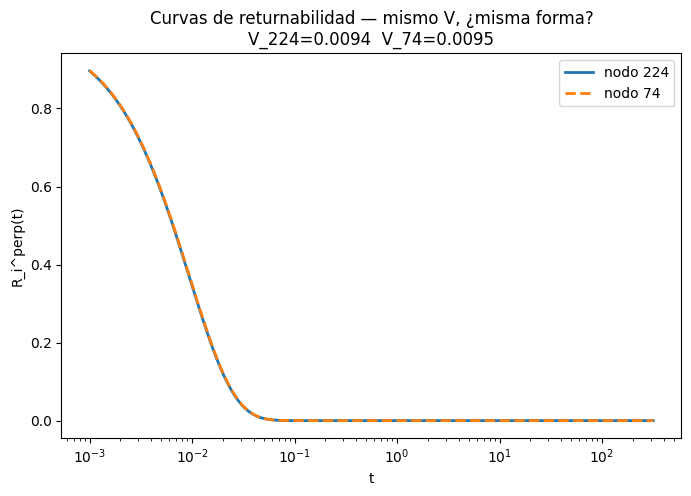

diferencia máxima absoluta entre curvas: 0.00347
diferencia máxima relativa: 0.004
la mayor diferencia ocurre en t = 0.009


In [ ]:
import matplotlib.pyplot as plt

Ts_plot = np.logspace(-3, 2.5, 200)
R_224 = R_perp_de_t(A, 224, Ts_plot)
R_74  = R_perp_de_t(A, 74, Ts_plot)

plt.figure(figsize=(8,5))
plt.plot(Ts_plot, R_224, label='nodo 224', lw=2)
plt.plot(Ts_plot, R_74, label='nodo 74', lw=2, linestyle='--')
plt.xscale('log')
plt.xlabel('t'); plt.ylabel('R_i^perp(t)')
plt.title(f'Curvas de returnabilidad — mismo V, ¿misma forma?\nV_224={V[224]:.4f}  V_74={V[74]:.4f}')
plt.legend()
plt.savefig('/content/curvas_mismo_V.png', dpi=150, bbox_inches='tight')  # o ruta local si es Jupyter
plt.show()

# métrica cuantitativa de qué tan distintas son las formas, no solo el área
diff_max = np.max(np.abs(np.array(R_224)-np.array(R_74)))
diff_rel = diff_max / max(np.max(R_224), np.max(R_74))
print(f"diferencia máxima absoluta entre curvas: {diff_max:.5f}")
print(f"diferencia máxima relativa: {diff_rel:.3f}")

# ¿en qué t difieren más?
t_max_diff = Ts_plot[np.argmax(np.abs(np.array(R_224)-np.array(R_74)))]
print(f"la mayor diferencia ocurre en t = {t_max_diff:.3f}")


In [ ]:
import numpy as np, networkx as nx
from scipy.linalg import eigh, expm
from scipy.stats import pearsonr

def benchmark_sensor(A, k_sensores=5, n_trials=50, T=2.0, seed=0):
    """
    Tarea: elegir k nodos como 'sensores'. Se inyecta una señal aleatoria
    transversal, se difunde T unidades de tiempo, y se mide qué tan bien
    los sensores elegidos por cada métrica permiten RECONSTRUIR el estado inicial
    (o, más simple: cuánta señal total capturan los sensores).
    Métrica de éxito: energía capturada por los sensores / energía total, promediada.
    """
    rng = np.random.default_rng(seed)
    N = A.shape[0]
    L = np.diag(A.sum(1)) - A
    deg = A.sum(1)

    # las métricas candidatas
    ev, evec = eigh(L)
    k0 = next(k for k in range(1,N) if ev[k]>1e-8)
    V = np.zeros(N)
    for k in range(k0,N): V += evec[:,k]**2/ev[k]

    G = nx.from_numpy_array(A)
    metricas = {
        'V (L+ii)': V,
        'grado': deg,
        'betweenness': np.array(list(nx.betweenness_centrality(G).values())),
        'eigenvector': np.array(list(nx.eigenvector_centrality_numpy(G).values())),
        'closeness': np.array(list(nx.closeness_centrality(G).values())),
    }

    E = expm(-L*T)
    resultados = {}
    for nombre, score in metricas.items():
        # sensores = los k nodos con MENOR V (mejor "retienen") o MAYOR para las otras
        # ojo con la direccion: V bajo = mal retenedor; usamos topk apropiado por métrica
        if nombre == 'V (L+ii)':
            sensores = np.argsort(-score)[:k_sensores]   # mayor V = mejor observador
        else:
            sensores = np.argsort(-score)[:k_sensores]   # mayor centralidad clasica

        capturas = []
        for _ in range(n_trials):
            x0 = rng.standard_normal(N)
            x0 -= x0.mean()  # transverso
            xT = E @ x0
            energia_total = np.sum(xT**2)
            energia_sensores = np.sum(xT[sensores]**2)
            capturas.append(energia_sensores/energia_total)
        resultados[nombre] = np.mean(capturas)

    return resultados

# correr en una red real
res = benchmark_sensor(A, k_sensores=5, n_trials=100)
print(f"{'métrica':15s} {'energía capturada (media)':>25s}")
for nom, val in sorted(res.items(), key=lambda x:-x[1]):
    print(f"{nom:15s} {val:>25.4f}")


métrica         energía capturada (media)
grado                              0.0232
eigenvector                        0.0225
betweenness                        0.0215
closeness                          0.0191
V (L+ii)                           0.0153


In [ ]:
# probar TAMBIÉN con V invertido: menor V = mejor sensor (el que más deja pasar)
def benchmark_sensor_v2(A, k_sensores=5, n_trials=100, T=2.0, seed=0):
    rng = np.random.default_rng(seed)
    N = A.shape[0]
    L = np.diag(A.sum(1)) - A
    ev, evec = eigh(L)
    k0 = next(k for k in range(1,N) if ev[k]>1e-8)
    V = np.zeros(N)
    for k in range(k0,N): V += evec[:,k]**2/ev[k]

    E = expm(-L*T)
    for etiqueta, sensores in [
        ('V alto (persistencia)', np.argsort(-V)[:k_sensores]),
        ('V bajo (tránsito)',     np.argsort(V)[:k_sensores]),
    ]:
        capturas = []
        for _ in range(n_trials):
            x0 = rng.standard_normal(N); x0 -= x0.mean()
            xT = E @ x0
            capturas.append(np.sum(xT[sensores]**2)/np.sum(xT**2))
        print(f"{etiqueta:24s}: energía capturada = {np.mean(capturas):.4f}")

benchmark_sensor_v2(A)


V alto (persistencia)   : energía capturada = 0.0153
V bajo (tránsito)       : energía capturada = 0.0232


In [ ]:
def benchmark_retencion(A, T=2.0, n_trials=100, seed=0):
    """
    Pregunta correcta: si perturbo el nodo i (SOLO i, no toda la red),
    ¿cuánta de SU PROPIA energía le queda a i después de tiempo T?
    Esto es exactamente lo que V predice por construcción:
    V_i = integral de 0 a inf de esa retención propia.
    """
    rng = np.random.default_rng(seed)
    N = A.shape[0]
    L = np.diag(A.sum(1)) - A
    E = expm(-L*T)

    energia_propia_T = np.zeros(N)
    for i in range(N):
        x0 = np.zeros(N); x0[i] = 1.0
        xT = E @ x0
        energia_propia_T[i] = xT[i]**2   # cuánta de SU energía le queda a él mismo

    # ahora comparamos: ¿V predice bien qué nodos retienen más su propia energía?
    ev, evec = eigh(L)
    k0 = next(k for k in range(1,N) if ev[k]>1e-8)
    V = np.zeros(N)
    for k in range(k0,N): V += evec[:,k]**2/ev[k]
    deg = A.sum(1)

    from scipy.stats import spearmanr
    print(f"Spearman(V, energía propia retenida a T={T}) = {spearmanr(V, energia_propia_T)[0]:+.4f}")
    print(f"Spearman(grado, energía propia retenida a T={T}) = {spearmanr(deg, energia_propia_T)[0]:+.4f}")
    print(f"Spearman(1/grado, energía propia retenida a T={T}) = {spearmanr(1/deg, energia_propia_T)[0]:+.4f}")

benchmark_retencion(A)


Spearman(V, energía propia retenida a T=2.0) = +0.4135
Spearman(grado, energía propia retenida a T=2.0) = -0.4127
Spearman(1/grado, energía propia retenida a T=2.0) = +0.4127


In [ ]:
import numpy as np
from scipy.linalg import eigh, expm
from scipy.stats import spearmanr

L = np.diag(A.sum(1)) - A   # <-- definir L aquí, en el espacio global
N = A.shape[0]

# recalcular V por si se perdió también
ev, evec = eigh(L)
k0 = next(k for k in range(1,N) if ev[k]>1e-8)
V = np.zeros(N)
for k in range(k0,N): V += evec[:,k]**2/ev[k]

# 1. escala real de la energía propia a distintos T
x0 = np.zeros(N); x0[0] = 1.0
E_chico = expm(-L*0.1) @ x0
E_medio = expm(-L*2.0) @ x0
print(f"energía propia nodo 0 en T=0.1: {E_chico[0]**2:.6f}")
print(f"energía propia nodo 0 en T=2.0: {E_medio[0]**2:.6f}")
print()

# 2. barrido de T para ver si la correlación con V sube en algún punto
for T in [0.01, 0.05, 0.1, 0.3, 0.5, 1.0, 2.0, 5.0]:
    ET = expm(-L*T)
    ep = np.array([ET[i,i]**2 for i in range(N)])   # energía propia de cada nodo a tiempo T
    print(f"T={T:5.2f}  Spearman(V, energía propia) = {spearmanr(V, ep)[0]:+.4f}")


# mira la escala real de la energia propia a T=2 vs a T chico
x0 = np.zeros(A.shape[0]); x0[0] = 1.0
E_chico = expm(-L*0.1) @ x0
E_medio = expm(-L*2.0) @ x0
print(f"energía propia nodo 0 en T=0.1: {E_chico[0]**2:.6f}")
print(f"energía propia nodo 0 en T=2.0: {E_medio[0]**2:.6f}")
# si a T=2 ya es minúscula y casi uniforme entre nodos, ahí está el problema

for T in [0.01, 0.05, 0.1, 0.3, 0.5, 1.0, 2.0, 5.0]:
    ET = expm(-L*T)
    ep = np.array([(ET[:,i][i])**2 for i in range(A.shape[0])])
    # ojo: mas eficiente hacerlo vectorizado, pero conceptualmente correcto
    print(f"T={T:5.2f}  Spearman(V, energía propia) = {spearmanr(V, ep)[0]:+.4f}")



energía propia nodo 0 en T=0.1: 0.000015
energía propia nodo 0 en T=2.0: 0.000011

T= 0.01  Spearman(V, energía propia) = +0.9999
T= 0.05  Spearman(V, energía propia) = +1.0000
T= 0.10  Spearman(V, energía propia) = +0.9999
T= 0.30  Spearman(V, energía propia) = +0.9903
T= 0.50  Spearman(V, energía propia) = +0.8841
T= 1.00  Spearman(V, energía propia) = +0.2879
T= 2.00  Spearman(V, energía propia) = +0.4135
T= 5.00  Spearman(V, energía propia) = -0.0085
energía propia nodo 0 en T=0.1: 0.000015
energía propia nodo 0 en T=2.0: 0.000011
T= 0.01  Spearman(V, energía propia) = +0.9999
T= 0.05  Spearman(V, energía propia) = +1.0000
T= 0.10  Spearman(V, energía propia) = +0.9999
T= 0.30  Spearman(V, energía propia) = +0.9903
T= 0.50  Spearman(V, energía propia) = +0.8841
T= 1.00  Spearman(V, energía propia) = +0.2879
T= 2.00  Spearman(V, energía propia) = +0.4135
T= 5.00  Spearman(V, energía propia) = -0.0085


In [ ]:
import numpy as np, pandas as pd, networkx as nx, os
from scipy.linalg import eigh, expm
from scipy.stats import spearmanr

def cargar(archivo):
    df = pd.read_csv(archivo, comment='#', header=None).iloc[:,:2]
    df.columns=['s','t']
    G = nx.Graph(); G.add_edges_from(df.values)
    G.remove_edges_from(nx.selfloop_edges(G))
    return G.subgraph(max(nx.connected_components(G),key=len)).copy()

def V_de(A, k0, ev, evec, N):
    V = np.zeros(N)
    for k in range(k0,N): V += evec[:,k]**2/ev[k]
    return V

def experimento_completo(A, Ts):
    """Prueba 1: rho(metrica, retencion(T)) para V, grado, current-flow, closeness."""
    N = A.shape[0]; deg = A.sum(1)
    L = np.diag(deg) - A
    ev, evec = eigh(L); k0 = next(k for k in range(1,N) if ev[k]>1e-8)
    V = V_de(A,k0,ev,evec,N)
    G = nx.from_numpy_array(A)
    cfc = np.array(list(nx.current_flow_closeness_centrality(G).values()))
    clo = np.array(list(nx.closeness_centrality(G).values()))

    print(f"{'T':>6s} {'rho(V,·)':>10s} {'rho(grado,·)':>13s} {'rho(cfc,·)':>11s} {'rho(clo,·)':>11s}")
    for T in Ts:
        ET = expm(-L*T)
        ret = np.array([ET[i,i]**2 for i in range(N)])
        print(f"{T:6.2f} {spearmanr(V,ret)[0]:>+10.4f} {spearmanr(deg,ret)[0]:>+13.4f} "
              f"{spearmanr(cfc,ret)[0]:>+11.4f} {spearmanr(clo,ret)[0]:>+11.4f}")

def T95_ranking(A, T_grid):
    """Prueba: en que T el ranking V(T) ya captura 95% del ranking V(inf), via Kendall."""
    from scipy.stats import kendalltau
    N = A.shape[0]; deg = A.sum(1)
    L = np.diag(deg) - A
    ev, evec = eigh(L); k0 = next(k for k in range(1,N) if ev[k]>1e-8)
    def V_de_T(T):
        VT = np.zeros(N)
        for k in range(k0,N):
            VT += evec[:,k]**2 * (1-np.exp(-ev[k]*T))/ev[k]
        return VT
    Vinf = V_de_T(1e6)
    for T in T_grid:
        kt = kendalltau(Vinf, V_de_T(T))[0]
        if kt >= 0.95:
            return T
    return None

def con_laplaciano_alternativo(A, tipo='sym'):
    """Repite V==1/k con L_sym o L_rw en vez de L combinatorio."""
    N = A.shape[0]; deg = A.sum(1)
    Dm = np.diag(1/np.sqrt(deg))
    if tipo == 'sym':
        L = np.eye(N) - Dm @ A @ Dm
    elif tipo == 'rw':
        L = np.eye(N) - np.diag(1/deg) @ A
    else:
        L = np.diag(deg) - A
    ev, evec = eigh(L); k0 = next(k for k in range(1,N) if ev[k]>1e-8)
    V = V_de(A,k0,ev,evec,N)
    from scipy.stats import pearsonr
    r2 = pearsonr(V, 1/deg)[0]**2
    sp = spearmanr(V, deg)[0]
    print(f"  Laplaciano {tipo:5s}: Spearman(V,grado)={sp:+.4f}  R²(V,1/k)={r2:.4f}")

# ==== correr en tus redes ====
CARPETA = '/content/drive/MyDrive/PYTHON/C.Elegans CSV' # ajusta
for arch, nom in [('celegans_metabolic.csv','metabolic'),
                  ('Neurons.csv','neural'), ('jazz_collab.csv','jazz')]:
    G = cargar(os.path.join(CARPETA,arch))
    A = nx.to_numpy_array(G)
    print(f"\n########## {nom} (N={A.shape[0]}) ##########")
    print("--- prueba 1: rho(metrica, retencion(T)) ---")
    experimento_completo(A, [0.01,0.05,0.1,0.3,0.5,1,2,5])
    print("--- prueba 2: mismo experimento con L normalizado y random-walk ---")
    for tipo in ['comb','sym','rw']:
        con_laplaciano_alternativo(A, tipo)



########## metabolic (N=453) ##########
--- prueba 1: rho(metrica, retencion(T)) ---
     T   rho(V,·)  rho(grado,·)  rho(cfc,·)  rho(clo,·)
  0.01    +0.9711       -0.9916     -0.9711     -0.6546
  0.05    +0.9751       -0.9916     -0.9751     -0.6391
  0.10    +0.9767       -0.9916     -0.9767     -0.6313
  0.30    +0.9813       -0.9911     -0.9813     -0.6197
  0.50    +0.9875       -0.9853     -0.9875     -0.6258
  1.00    +0.9783       -0.9283     -0.9783     -0.6409
  2.00    +0.8956       -0.8025     -0.8956     -0.6171
  5.00    +0.7552       -0.6381     -0.7552     -0.5907
--- prueba 2: mismo experimento con L normalizado y random-walk ---
  Laplaciano comb : Spearman(V,grado)=-0.9623  R²(V,1/k)=0.7715
  Laplaciano sym  : Spearman(V,grado)=-0.1818  R²(V,1/k)=0.0336
  Laplaciano rw   : Spearman(V,grado)=-0.0899  R²(V,1/k)=0.0307

########## neural (N=297) ##########
--- prueba 1: rho(metrica, retencion(T)) ---
     T   rho(V,·)  rho(grado,·)  rho(cfc,·)  rho(clo,·)
  0.01    +

In [ ]:
import numpy as np
from scipy.linalg import eigh, expm
from scipy.integrate import quad

def verificar_identidad_sym(A, i_nodo=0):
    N = A.shape[0]; deg = A.sum(1)
    Dm = np.diag(1/np.sqrt(deg))
    L_sym = np.eye(N) - Dm @ A @ Dm
    ev, evec = eigh(L_sym)
    k0 = next(k for k in range(1,N) if ev[k]>1e-8)

    # V via suma espectral (lo que ya calculamos)
    V_espectral = sum(evec[i_nodo,k]**2/ev[k] for k in range(k0,N))

    # V via integral directa de (e^{-t L_sym})_ii
    def R_perp(t):
        return sum(np.exp(-ev[k]*t)*evec[i_nodo,k]**2 for k in range(k0,N))
    V_integral, err = quad(R_perp, 0, np.inf)

    print(f"nodo {i_nodo}:")
    print(f"  V (suma espectral)  = {V_espectral:.8f}")
    print(f"  V (integral directa)= {V_integral:.8f}")
    print(f"  diferencia          = {abs(V_espectral-V_integral):.2e}")

# probar en varios nodos
for i in [0, 10, 50]:
    verificar_identidad_sym(A, i)


nodo 0:
  V (suma espectral)  = 1.04925324
  V (integral directa)= 1.04925324
  diferencia          = 2.31e-14
nodo 10:
  V (suma espectral)  = 1.02738189
  V (integral directa)= 1.02738189
  diferencia          = 2.46e-14
nodo 50:
  V (suma espectral)  = 1.05607929
  V (integral directa)= 1.05607929
  diferencia          = 6.66e-16


In [ ]:
import numpy as np, pandas as pd, networkx as nx, os
from scipy.linalg import eigh
from scipy.stats import spearmanr

def V_de_L(L):
    N = L.shape[0]
    ev, evec = eigh(L)
    k0 = next(k for k in range(1,N) if ev[k]>1e-8)
    V = np.zeros(N)
    for k in range(k0,N): V += evec[:,k]**2/ev[k]
    return V

def interpolacion_operadores(A, alphas):
    N = A.shape[0]; deg = A.sum(1)
    L_comb = np.diag(deg) - A
    Dm = np.diag(1/np.sqrt(deg))
    L_sym = np.eye(N) - Dm @ A @ Dm

    print(f"{'alpha':>6s} {'Sp(V,grado)':>13s}")
    resultados = []
    for a in alphas:
        L_a = (1-a)*L_comb + a*L_sym
        # L(a) sigue siendo simetrica (combinacion de dos simetricas), eigh es valido
        V_a = V_de_L(L_a)
        rho = spearmanr(V_a, deg)[0]
        resultados.append((a, rho))
        print(f"{a:6.2f} {rho:>+13.4f}")
    return resultados

CARPETA = '/content/drive/MyDrive/PYTHON/C.Elegans CSV'
alphas = np.linspace(0, 1, 21)  # 0.00, 0.05, ..., 1.00

for arch, nom in [('celegans_metabolic.csv','metabolic'),
                  ('Neurons.csv','neural'),
                  ('jazz_collab.csv','jazz')]:
    df = pd.read_csv(os.path.join(CARPETA,arch), comment='#', header=None).iloc[:,:2]
    df.columns=['s','t']
    G = nx.Graph(); G.add_edges_from(df.values)
    G.remove_edges_from(nx.selfloop_edges(G))
    G = G.subgraph(max(nx.connected_components(G),key=len)).copy()
    A = nx.to_numpy_array(G)
    print(f"\n########## {nom} (N={A.shape[0]}) ##########")
    interpolacion_operadores(A, alphas)



########## metabolic (N=453) ##########
 alpha   Sp(V,grado)
  0.00       -0.9623
  0.05       -0.9621
  0.10       -0.9619
  0.15       -0.9616
  0.20       -0.9613
  0.25       -0.9609
  0.30       -0.9603
  0.35       -0.9598
  0.40       -0.9592
  0.45       -0.9587
  0.50       -0.9582
  0.55       -0.9575
  0.60       -0.9559
  0.65       -0.9544
  0.70       -0.9492
  0.75       -0.9337
  0.80       -0.9207
  0.85       -0.9061
  0.90       -0.8846
  0.95       -0.8307
  1.00       -0.1818

########## neural (N=297) ##########
 alpha   Sp(V,grado)
  0.00       -0.9979
  0.05       -0.9979
  0.10       -0.9979
  0.15       -0.9979
  0.20       -0.9979
  0.25       -0.9979
  0.30       -0.9979
  0.35       -0.9978
  0.40       -0.9978
  0.45       -0.9978
  0.50       -0.9977
  0.55       -0.9977
  0.60       -0.9976
  0.65       -0.9975
  0.70       -0.9974
  0.75       -0.9971
  0.80       -0.9969
  0.85       -0.9964
  0.90       -0.9951
  0.95       -0.9888
  1.00       +0.08

In [ ]:
import numpy as np, pandas as pd, networkx as nx, os
from scipy.linalg import eigh
from scipy.stats import spearmanr

def V_de_L(L):
    N = L.shape[0]
    ev, evec = eigh(L)
    k0 = next(k for k in range(1,N) if ev[k]>1e-8)
    V = np.zeros(N)
    for k in range(k0,N): V += evec[:,k]**2/ev[k]
    return V

def barrido_gamma(A, gammas):
    N = A.shape[0]; deg = A.sum(1)
    L = np.diag(deg) - A
    print(f"{'gamma':>7s} {'Sp(V,grado)':>13s}")
    for g in gammas:
        Dg = np.diag(deg**(-g))
        L_g = Dg @ L @ Dg          # D^-gamma L D^-gamma
        V_g = V_de_L(L_g)
        rho = spearmanr(V_g, deg)[0]
        print(f"{g:7.3f} {rho:>+13.4f}")

CARPETA = '/content/drive/MyDrive/PYTHON/C.Elegans CSV'
gammas = np.linspace(0, 0.5, 21)   # 0 = combinatorio, 0.5 = normalizado simetrico

for arch, nom in [('celegans_metabolic.csv','metabolic'),
                  ('Neurons.csv','neural'), ('jazz_collab.csv','jazz')]:
    df = pd.read_csv(os.path.join(CARPETA,arch), comment='#', header=None).iloc[:,:2]
    df.columns=['s','t']
    G = nx.Graph(); G.add_edges_from(df.values)
    G.remove_edges_from(nx.selfloop_edges(G))
    G = G.subgraph(max(nx.connected_components(G),key=len)).copy()
    A = nx.to_numpy_array(G)
    print(f"\n########## {nom} ##########")
    barrido_gamma(A, gammas)



########## metabolic ##########
  gamma   Sp(V,grado)
  0.000       -0.9623
  0.025       -0.9600
  0.050       -0.9577
  0.075       -0.9550
  0.100       -0.9526
  0.125       -0.9485
  0.150       -0.9451
  0.175       -0.9417
  0.200       -0.9373
  0.225       -0.9319
  0.250       -0.9270
  0.275       -0.9210
  0.300       -0.9134
  0.325       -0.9044
  0.350       -0.8911
  0.375       -0.8734
  0.400       -0.8485
  0.425       -0.8078
  0.450       -0.7252
  0.475       -0.5432
  0.500       -0.1818

########## neural ##########
  gamma   Sp(V,grado)
  0.000       -0.9979
  0.025       -0.9977
  0.050       -0.9974
  0.075       -0.9971
  0.100       -0.9969
  0.125       -0.9965
  0.150       -0.9961
  0.175       -0.9956
  0.200       -0.9950
  0.225       -0.9940
  0.250       -0.9929
  0.275       -0.9912
  0.300       -0.9889
  0.325       -0.9855
  0.350       -0.9806
  0.375       -0.9722
  0.400       -0.9586
  0.425       -0.9323
  0.450       -0.8745
  0.475      

In [ ]:
def residuo_estructural(A):
    N = A.shape[0]; deg = A.sum(1)
    L = np.diag(deg) - A
    V = V_de_L(L)
    # ajuste V ~ a/k + b
    X = np.vstack([1/deg, np.ones(N)]).T
    coef, *_ = np.linalg.lstsq(X, V, rcond=None)
    a, b = coef
    V_pred = a/deg + b
    residuo = V - V_pred
    r2 = 1 - np.sum(residuo**2)/np.sum((V-V.mean())**2)
    print(f"  ajuste V ~ {a:.4f}/k + {b:.4f}   R²={r2:.4f}")
    return residuo, deg

def residuo_vs_estructura(A, G):
    residuo, deg = residuo_estructural(A)
    clus = np.array(list(nx.clustering(G).values()))
    btw  = np.array(list(nx.betweenness_centrality(G).values()))
    core = np.array(list(nx.core_number(G).values()))
    try:
        import networkx.algorithms.community as nxcom
        comms = nxcom.louvain_communities(G, seed=42)
        comm_of = {n:i for i,c in enumerate(comms) for n in c}
        nodes = list(G.nodes())
        part = []
        for n in nodes:
            counts = {}
            for nb in G.neighbors(n):
                c = comm_of[nb]; counts[c]=counts.get(c,0)+1
            k = G.degree(n)
            part.append(1-sum((v/k)**2 for v in counts.values()) if k>0 else 0)
        part = np.array(part)
    except Exception as e:
        part = None

    print(f"  Spearman(residuo, clustering)   = {spearmanr(residuo,clus)[0]:+.4f}")
    print(f"  Spearman(residuo, betweenness)  = {spearmanr(residuo,btw)[0]:+.4f}")
    print(f"  Spearman(residuo, core_number)  = {spearmanr(residuo,core)[0]:+.4f}")
    if part is not None:
        print(f"  Spearman(residuo, participation)= {spearmanr(residuo,part)[0]:+.4f}")

for arch, nom in [('celegans_metabolic.csv','metabolic'),
                  ('Neurons.csv','neural'), ('jazz_collab.csv','jazz')]:
    df = pd.read_csv(os.path.join(CARPETA,arch), comment='#', header=None).iloc[:,:2]
    df.columns=['s','t']
    G = nx.Graph(); G.add_edges_from(df.values)
    G.remove_edges_from(nx.selfloop_edges(G))
    G = G.subgraph(max(nx.connected_components(G),key=len)).copy()
    A = nx.to_numpy_array(G)
    print(f"\n########## {nom} ##########")
    residuo_vs_estructura(A, G)



########## metabolic ##########
  ajuste V ~ 1.4930/k + -0.0454   R²=0.7715
  Spearman(residuo, clustering)   = -0.5185
  Spearman(residuo, betweenness)  = +0.6174
  Spearman(residuo, core_number)  = +0.4266
  Spearman(residuo, participation)= +0.1352

########## neural ##########
  ajuste V ~ 1.0119/k + 0.0070   R²=0.9990
  Spearman(residuo, clustering)   = +0.2499
  Spearman(residuo, betweenness)  = -0.4405
  Spearman(residuo, core_number)  = -0.6064
  Spearman(residuo, participation)= -0.4297

########## jazz ##########
  ajuste V ~ 1.1554/k + -0.0001   R²=0.9508
  Spearman(residuo, clustering)   = -0.2921
  Spearman(residuo, betweenness)  = +0.6167
  Spearman(residuo, core_number)  = +0.3646
  Spearman(residuo, participation)= -0.1900


In [ ]:
# verificar si el residuo de neural es simplemente muy pequeño (ruido) vs sustancial
for arch, nom in [('celegans_metabolic.csv','metabolic'),
                  ('Neurons.csv','neural'), ('jazz_collab.csv','jazz')]:
    # ... cargar G, A ...
    residuo, deg = residuo_estructural(A)
    V = V_de_L(np.diag(A.sum(1))-A)
    print(f"{nom}: residuo/V medio = {np.mean(np.abs(residuo)/np.abs(V)):.4f}  "
          f"(qué fracción de V es el residuo, en promedio)")


  ajuste V ~ 1.1554/k + -0.0001   R²=0.9508
metabolic: residuo/V medio = 0.0710  (qué fracción de V es el residuo, en promedio)
  ajuste V ~ 1.1554/k + -0.0001   R²=0.9508
neural: residuo/V medio = 0.0710  (qué fracción de V es el residuo, en promedio)
  ajuste V ~ 1.1554/k + -0.0001   R²=0.9508
jazz: residuo/V medio = 0.0710  (qué fracción de V es el residuo, en promedio)


In [ ]:
CARPETA = '/content/drive/MyDrive/PYTHON/C.Elegans CSV'

for arch, nom in [('celegans_metabolic.csv','metabolic'),
                  ('Neurons.csv','neural'),
                  ('jazz_collab.csv','jazz')]:
    # carga fresca en CADA iteración, sin reusar nada de fuera
    df = pd.read_csv(os.path.join(CARPETA,arch), comment='#', header=None).iloc[:,:2]
    df.columns=['s','t']
    G = nx.Graph(); G.add_edges_from(df.values)
    G.remove_edges_from(nx.selfloop_edges(G))
    G = G.subgraph(max(nx.connected_components(G),key=len)).copy()
    A = nx.to_numpy_array(G)

    print(f"\n########## {nom} (N={A.shape[0]}, aristas={int(A.sum()/2)}) ##########")
    residuo, deg = residuo_estructural(A)
    V = V_de_L(np.diag(A.sum(1))-A)
    frac = np.mean(np.abs(residuo)/np.abs(V))
    print(f"  residuo/V medio = {frac:.4f}")
    print("  --- descomposición modal ---")
    descomposicion_modal(A)



########## metabolic (N=453, aristas=2025) ##########
  ajuste V ~ 1.4930/k + -0.0454   R²=0.7715
  residuo/V medio = 0.2539
  --- descomposición modal ---
 m_modos  % modos  Sp(V^m,grado)
       1     0.2%        -0.3548
      24     5.3%        -0.5508
      48    10.6%        -0.6543
      72    15.9%        -0.7394
      95    21.0%        -0.7978
     119    26.3%        -0.8509
     143    31.6%        -0.9170
     167    36.9%        -0.9291
     190    42.0%        -0.9451
     214    47.3%        -0.9503
     238    52.7%        -0.9597
     262    58.0%        -0.9613
     285    63.1%        -0.9649
     309    68.4%        -0.9645
     333    73.7%        -0.9665
     357    79.0%        -0.9645
     380    84.1%        -0.9645
     404    89.4%        -0.9642
     428    94.7%        -0.9623
     452   100.0%        -0.9623

########## neural (N=297, aristas=2148) ##########
  ajuste V ~ 1.0119/k + 0.0070   R²=0.9990
  residuo/V medio = 0.0506
  --- descomposición modal -

In [ ]:
import numpy as np, pandas as pd, networkx as nx, os
from scipy.linalg import eigh
from scipy.stats import pearsonr, spearmanr

def R2_vs_propiedades(archivo, nombre):
    df = pd.read_csv(archivo, comment='#', header=None).iloc[:,:2]
    df.columns=['s','t']
    G = nx.Graph(); G.add_edges_from(df.values)
    G.remove_edges_from(nx.selfloop_edges(G))
    G = G.subgraph(max(nx.connected_components(G),key=len)).copy()
    A = nx.to_numpy_array(G); N=A.shape[0]; deg=A.sum(1)
    ev, evec = eigh(np.diag(deg)-A)
    k0 = next(k for k in range(1,N) if ev[k]>1e-8)
    V = np.zeros(N)
    for k in range(k0,N): V += evec[:,k]**2/ev[k]

    r2 = pearsonr(V, 1/deg)[0]**2
    cv = deg.std()/deg.mean()
    dens = A.sum()/(N*(N-1))
    asort = nx.degree_assortativity_coefficient(G)
    clus = nx.average_clustering(G)
    print(f"{nombre:14s} N={N:5d} R2={r2:.3f} CV={cv:.2f} dens={dens:.4f} "
          f"asort={asort:+.3f} clus={clus:.3f}")
    return dict(nombre=nombre, r2=r2, cv=cv, dens=dens, asort=asort, clus=clus)

CARPETA = '/content/drive/MyDrive/PYTHON/C.Elegans CSV'# o donde tengas todas
archivos = [
    ('celegans_metabolic.csv','metabolic'), ('Neurons.csv','neural'),
    ('jazz_collab.csv','jazz'), ('foodweb_little_rock.csv','foodweb'),
    ('bitcoin_alpha.csv','bitcoin'),('fly_larva.csv','flylarva'),('Genetic.csv','genetic')
]
resultados = []
for arch, nom in archivos:
    ruta = os.path.join(CARPETA, arch)
    if os.path.isfile(ruta):
        resultados.append(R2_vs_propiedades(ruta, nom))

if len(resultados) >= 4:
    r2s = [r['r2'] for r in resultados]
    print("\ncorrelaciones con R2 (sobre", len(resultados), "redes):")
    for key in ['cv','dens','asort','clus']:
        vals = [r[key] for r in resultados]
        print(f"  Spearman(R2, {key:6s}) = {spearmanr(r2s, vals)[0]:+.3f}")
else:
    print("\nfaltan redes -- necesitas al menos 5-6 para que la correlacion tenga sentido")


metabolic      N=  453 R2=0.772 CV=1.87 dens=0.0198 asort=-0.226 clus=0.646
neural         N=  297 R2=0.999 CV=0.89 dens=0.0489 asort=-0.163 clus=0.292
jazz           N=  198 R2=0.951 CV=0.63 dens=0.1406 asort=+0.020 clus=0.617
foodweb        N=  183 R2=1.000 CV=0.78 dens=0.1462 asort=-0.266 clus=0.323
bitcoin        N= 3775 R2=0.873 CV=2.68 dens=0.0020 asort=-0.169 clus=0.177
flylarva       N= 2952 R2=0.930 CV=0.66 dens=0.0220 asort=+0.237 clus=0.261
genetic        N=  683 R2=0.491 CV=1.18 dens=0.0066 asort=-0.055 clus=0.245

correlaciones con R2 (sobre 7 redes):
  Spearman(R2, cv    ) = -0.571
  Spearman(R2, dens  ) = +0.857
  Spearman(R2, asort ) = -0.179
  Spearman(R2, clus  ) = +0.286


In [ ]:
import numpy as np
from scipy.stats import spearmanr

datos = [
    ('metabolic',0.772,1.87,0.0198,-0.226,0.646),
    ('neural',0.999,0.89,0.0489,-0.163,0.292),
    ('jazz',0.951,0.63,0.1406,0.020,0.617),
    ('foodweb',1.000,0.78,0.1462,-0.266,0.323),
    ('bitcoin',0.873,2.68,0.0020,-0.169,0.177),
    ('flylarva',0.930,0.66,0.0220,0.237,0.261),
    ('genetic',0.491,1.18,0.0066,-0.055,0.245),
]

# sin genetic
sin_genetic = [d for d in datos if d[0]!='genetic']
r2s = [d[1] for d in sin_genetic]
dens = [d[3] for d in sin_genetic]
print(f"Spearman(R2,dens) SIN genetic (n={len(sin_genetic)}): {spearmanr(r2s,dens)[0]:+.3f}")

# con log(densidad), porque la densidad varia en ordenes de magnitud (0.002 a 0.146)
log_dens = [np.log(d[3]) for d in datos]
r2s_todos = [d[1] for d in datos]
print(f"Pearson(R2, log(dens)) con las 7: {np.corrcoef(r2s_todos, log_dens)[0,1]:+.3f}")


Spearman(R2,dens) SIN genetic (n=6): +0.886
Pearson(R2, log(dens)) con las 7: +0.568


interactome    N=  161 R2=0.482 CV=1.12 dens=0.0162 asort=-0.466 clus=0.007
bitcoin        N= 5875 R2=0.898 CV=3.15 dens=0.0012 asort=-0.165 clus=0.178
yeast          N=  664 R2=0.384 CV=1.79 dens=0.0048 asort=-0.408 clus=0.049
stezl          N= 1615 R2=0.532 CV=1.85 dens=0.0024 asort=-0.202 clus=0.006

n=11
Spearman(R2,dens) = +0.600
Pearson(R2, log(dens)) = +0.460


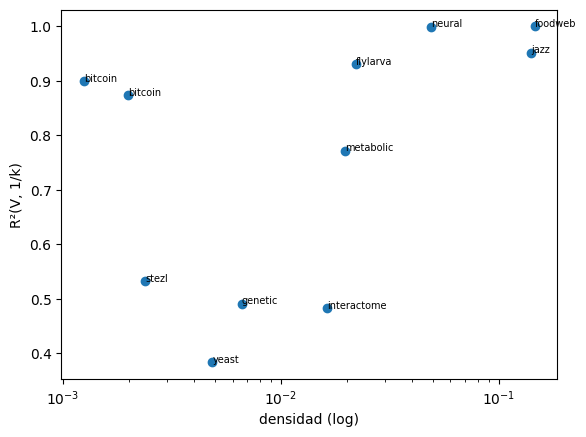

In [ ]:
# agrega estas líneas a la función de antes conforme sumes redes
archivos_nuevos = [
    ('interactome_pdz.csv','interactome'),
    ('bitcoin.csv','bitcoin'),('yeast_transcription.csv','yeast'),
    ('interactome_stelzl.csv','stezl'),
]
for arch, nom in archivos_nuevos:
    ruta = os.path.join(CARPETA, arch)
    if os.path.isfile(ruta):
        resultados.append(R2_vs_propiedades(ruta, nom))

# recalcular con todo junto
r2s = [r['r2'] for r in resultados]
dens = [r['dens'] for r in resultados]
print(f"\nn={len(resultados)}")
print(f"Spearman(R2,dens) = {spearmanr(r2s,dens)[0]:+.3f}")
print(f"Pearson(R2, log(dens)) = {np.corrcoef(r2s, np.log(dens))[0,1]:+.3f}")

# y grafica para ver la forma real, no solo el numero resumen
import matplotlib.pyplot as plt
plt.scatter(dens, r2s)
plt.xscale('log')
plt.xlabel('densidad (log)'); plt.ylabel('R²(V, 1/k)')
for r in resultados:
    plt.annotate(r['nombre'], (r['dens'], r['r2']), fontsize=7)
plt.savefig('R2_vs_densidad.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
from sklearn.linear_model import LinearRegression
X = np.array([[r['cv'], np.log(r['dens']), r['clus'], r['asort']] for r in resultados])
y = np.array([r['r2'] for r in resultados])
reg = LinearRegression().fit(X, y)
print(f"R² del modelo combinado (n={len(resultados)}): {reg.score(X,y):.3f}")
print(f"coeficientes: CV={reg.coef_[0]:+.3f} log(dens)={reg.coef_[1]:+.3f} "
      f"clus={reg.coef_[2]:+.3f} asort={reg.coef_[3]:+.3f}")


R² del modelo combinado (n=11): 0.931
coeficientes: CV=+0.551 log(dens)=+0.342 clus=-0.769 asort=+1.150


In [ ]:
np.random.seed(0)
ruido = np.random.randn(len(resultados))
X_con_ruido = np.array([[r['cv'], np.log(r['dens']), r['clus'], r['asort']] for r in resultados])
X_con_ruido = np.column_stack([X_con_ruido, ruido])

reg2 = LinearRegression().fit(X_con_ruido, y)
print(f"R² con 5 variables (4 reales + 1 ruido puro), n={len(resultados)}: {reg2.score(X_con_ruido,y):.3f}")

# y el test real: validacion cruzada dejando una fuera
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut
loo = LeaveOneOut()
preds = []
for train_idx, test_idx in loo.split(X):
    reg_cv = LinearRegression().fit(X[train_idx], y[train_idx])
    preds.append(reg_cv.predict(X[test_idx])[0])
preds = np.array(preds)
r2_cv = 1 - np.sum((y-preds)**2)/np.sum((y-y.mean())**2)
print(f"R² con validación cruzada leave-one-out: {r2_cv:.3f}   <-- este es el número real")


R² con 5 variables (4 reales + 1 ruido puro), n=11: 0.931
R² con validación cruzada leave-one-out: 0.829   <-- este es el número real


In [ ]:
r2s_ruido = []
for seed in range(20):
    np.random.seed(seed)
    ruido = np.random.randn(len(resultados))
    Xr = np.column_stack([X, ruido])
    r2s_ruido.append(LinearRegression().fit(Xr, y).score(Xr, y))
print(f"R² con ruido, 20 semillas: media={np.mean(r2s_ruido):.3f} min={min(r2s_ruido):.3f} max={max(r2s_ruido):.3f}")


R² con ruido, 20 semillas: media=0.946 min=0.931 max=0.994


In [ ]:
for i, r in enumerate(resultados):
    print(f"{r['nombre']:14s} y_real={y[i]:.3f}  y_predicho(LOO)={preds[i]:.3f}  "
          f"error={abs(y[i]-preds[i]):.3f}")


metabolic      y_real=0.772  y_predicho(LOO)=0.646  error=0.126
neural         y_real=0.999  y_predicho(LOO)=0.825  error=0.174
jazz           y_real=0.951  y_predicho(LOO)=1.091  error=0.140
foodweb        y_real=1.000  y_predicho(LOO)=1.063  error=0.063
bitcoin        y_real=0.873  y_predicho(LOO)=0.807  error=0.066
flylarva       y_real=0.930  y_predicho(LOO)=0.959  error=0.029
genetic        y_real=0.491  y_predicho(LOO)=0.488  error=0.003
interactome    y_real=0.482  y_predicho(LOO)=0.472  error=0.010
bitcoin        y_real=0.898  y_predicho(LOO)=0.980  error=0.082
yeast          y_real=0.384  y_predicho(LOO)=0.499  error=0.116
stezl          y_real=0.532  y_predicho(LOO)=0.525  error=0.007
